<h1 align="center">~Projektni zadatak - prva faza~</h1> 
<h2 align="center">Hardversko - softverska obrada signala (13E044HSOS)</h2> 
<h3 align="left">Student: Magdalena Savić</h3> 
<h3 align="left">Broj indeksa: 2022/0351</h3> 

In [1]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import math
from remezhb import remezhb
from remezlp import remezlp

fs_in = 61.44e6 # ulazna ucestanost odabiranja
fmax  = 25.0e6 # korisni opseg: -25..+25 MHz
AdB   = 60.0 # trazeno potiskivanje
delta = 10.0**(-AdB/20.0)

In [2]:
def readSamples(fileName):
    out = []
    with open(fileName, "r") as f:
        for line in f:
            out.append(complex(line))
    return np.array(out)

def plot_spec(x, fs, filename, title, mask=None):
    n = len(x)
    freqs = (np.arange(n)/n - 0.5) * fs/1e6
    plt.figure(figsize=(6,3.2))
    plt.plot(freqs, 20*np.log10(np.fft.fftshift(np.abs(np.fft.fft(x)))+1e-12), lw=0.8)
    if mask is not None:
        Fpass, Fstop = mask
        e  = [-0.5, -Fstop, -Fpass, Fpass, Fstop, 0.5]
        ax = [f_*fs/1e6 for f_ in e]
        ay = [-80,-80,5,5,-80,-80]
        plt.plot(ax, ay, "r--", lw=1.0, label="granice filtra")
        plt.legend(fontsize=8, loc="upper right")
    plt.xlabel("f [MHz]"); plt.ylabel("|X(f)| [dB]")
    plt.title(title); plt.ylim(-80,10); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(filename, dpi=130); plt.show()

def interp_stage(x, h, M):
    N = len(h)
    up = np.zeros(len(x)*M, dtype=complex)
    up[::M] = x
    ext = np.concatenate((up[-(N-1):], up)) 
    y = signal.lfilter(h, 1, ext)[N-1:]
    y = np.roll(y, -(N//2))                      
    return up, y

### 1. zadatak 

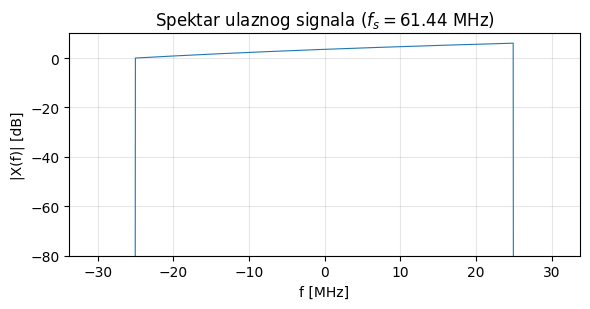

In [3]:
testsignal = readSamples("testsignal.txt")
plot_spec(testsignal, fs_in, "spektar_ulaz.png", "Spektar ulaznog signala ($f_s=61.44$ MHz)")

Broj koeficijenata H1 (HB1): 39


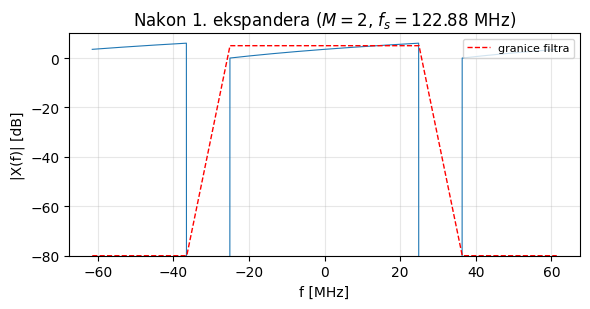

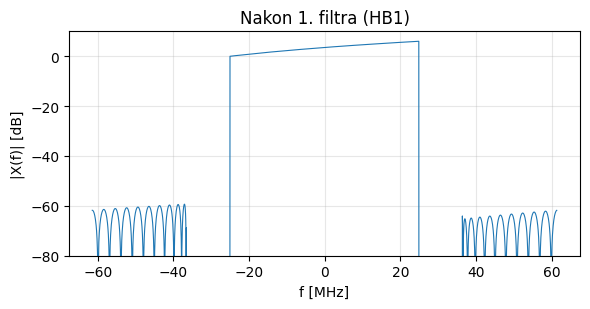

In [4]:
# 1. Stepen (M=2)
h1 = remezhb(fmax/(2*fs_in), AdB)
up1, y1 = interp_stage(testsignal, h1, 2)
print(f"Broj koeficijenata H1 (HB1): {len(h1)}")
plot_spec(up1, 2*fs_in, "spektar_exp1.png", "Nakon 1. ekspandera ($M{=}2$, $f_s{=}122.88$ MHz)", mask=(fmax/(2*fs_in), (fs_in-fmax)/(2*fs_in)))
plot_spec(y1, 2*fs_in, "spektar_filt1.png", "Nakon 1. filtra (HB1)")

Broj koeficijenata H2 (HB2): 11


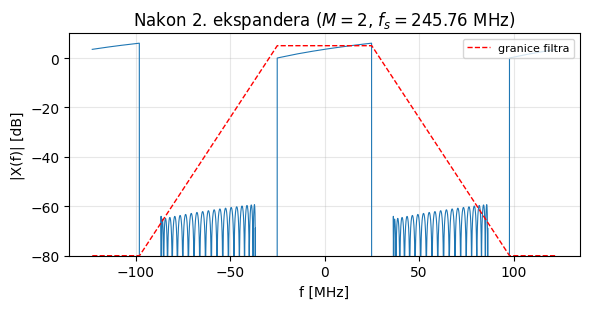

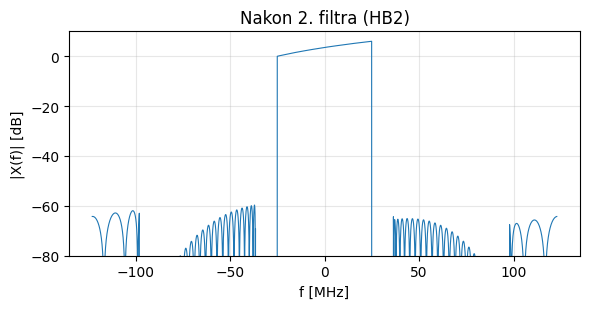

In [5]:
# 2. Stepen (M=2)
h2 = remezhb(fmax/(4*fs_in), AdB)
up2, y2 = interp_stage(y1, h2, 2)
print(f"Broj koeficijenata H2 (HB2): {len(h2)}")
plot_spec(up2, 4*fs_in, "spektar_exp2.png", "Nakon 2. ekspandera ($M{=}2$, $f_s{=}245.76$ MHz)", mask=(fmax/(4*fs_in), (2*fs_in-fmax)/(4*fs_in)))
plot_spec(y2, 4*fs_in, "spektar_filt2.png", "Nakon 2. filtra (HB2)")

Broj koeficijenata H3 (HB3): 7


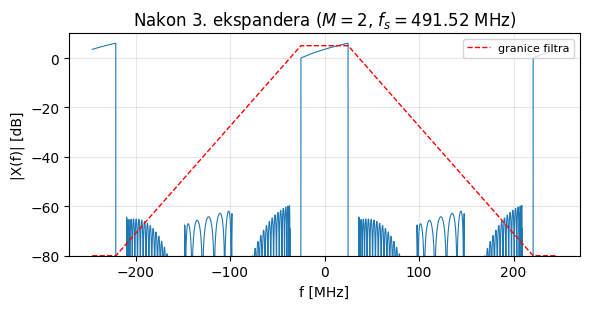

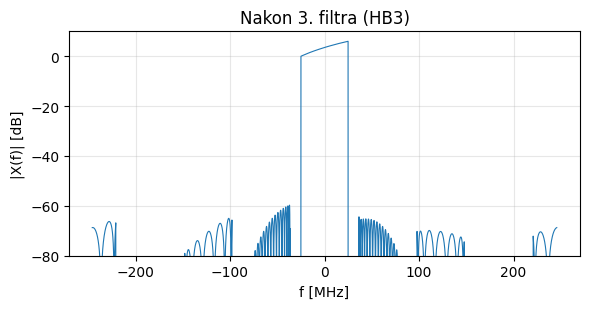

In [6]:
# 3. Stepen (M=2)
h3 = remezhb(fmax/(8*fs_in), AdB)
up3, y3 = interp_stage(y2, h3, 2)
print(f"Broj koeficijenata H3 (HB3): {len(h3)}")
plot_spec(up3, 8*fs_in, "spektar_exp3.png", "Nakon 3. ekspandera ($M{=}2$, $f_s{=}491.52$ MHz)", mask=(fmax/(8*fs_in), (4*fs_in-fmax)/(8*fs_in)))
plot_spec(y3, 8*fs_in, "spektar_filt3.png", "Nakon 3. filtra (HB3)")

Broj koeficijenata H4 (LP4): 6


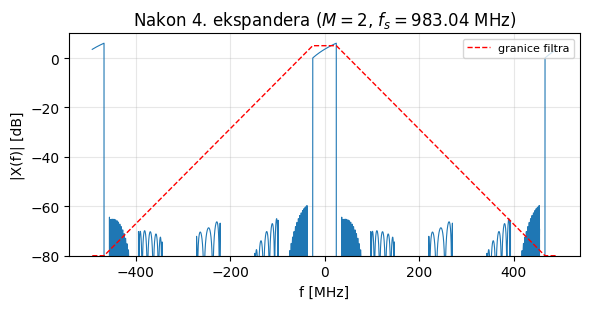

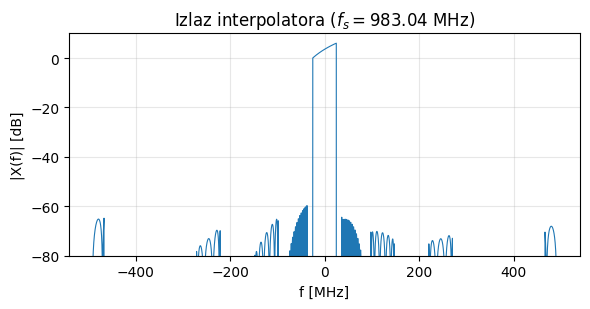

In [7]:
# 4. Stepen (M=2) 
Fpass4 = fmax/(16*fs_in)
Fstop4 = (8*fs_in - fmax)/(16*fs_in)
h4 = remezlp(Fpass4, Fstop4, delta, delta)
up4, y4 = interp_stage(y3, h4, 2)
print(f"Broj koeficijenata H4 (LP4): {len(h4)}")
plot_spec(up4, 16*fs_in, "spektar_exp4.png", "Nakon 4. ekspandera ($M{=}2$, $f_s{=}983.04$ MHz)", mask=(Fpass4, Fstop4))
plot_spec(y4, 16*fs_in, "spektar_izlaz_interpolatora.png", "Izlaz interpolatora ($f_s{=}983.04$ MHz)")

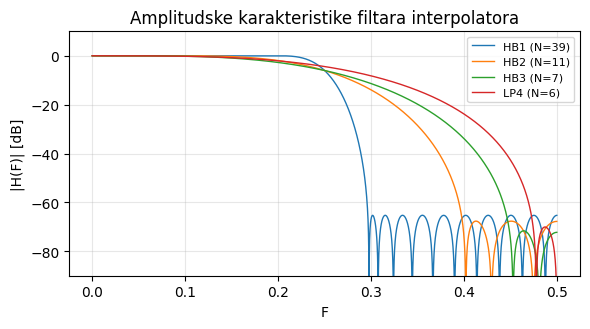

In [8]:
# Amplitudske karakteristike sva cetiri filtra
plt.figure(figsize=(6,3.4))
for h, name in [(h1,"HB1"),(h2,"HB2"),(h3,"HB3"),(h4,"LP4")]:
    w, H = signal.freqz(h, worN=4096)
    plt.plot(w/(2*np.pi), 20*np.log10(np.abs(H)+1e-12), lw=1.0, label=f"{name} (N={len(h)})")
plt.ylim(-90,10); plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.xlabel("F"); plt.ylabel("|H(F)| [dB]")
plt.title("Amplitudske karakteristike filtara interpolatora")
plt.tight_layout(); plt.savefig("filtri_interpolatora.png", dpi=130); plt.show()

In [9]:
stages = [
    ("HB1 (M=2)", len(h1),  fs_in,   fmax/(2*fs_in),  (fs_in-fmax)/(2*fs_in)),
    ("HB2 (M=2)", len(h2), 2*fs_in,  fmax/(4*fs_in),  (2*fs_in-fmax)/(4*fs_in)),
    ("HB3 (M=2)", len(h3), 4*fs_in,  fmax/(8*fs_in),  (4*fs_in-fmax)/(8*fs_in)),
    ("LP4 (M=2)", len(h4), 8*fs_in,  Fpass4,          Fstop4),
]
print(f"{'Stepen':<11}{'N':>4}{'f_ulaz[MHz]':>13}{'Fpass':>9}{'Fstop':>9}{'MOPs':>10}")
nop = 0.0
for name, N, fin, Fp, Fst in stages:
    mops = N*fin/1e6
    nop += mops
    print(f"{name:<11}{N:>4}{fin/1e6:>13.2f}{Fp:>9.4f}{Fst:>9.4f}{mops:>10.1f}")
print(f"{'UKUPNO':<11}{'':>4}{'':>13}{'':>9}{'':>9}{nop:>10.1f}")

Fp  = fmax/(16*fs_in); Fst = (fs_in-fmax)/(16*fs_in); dF = Fst-Fp
Ndir = int(np.ceil(AdB/(22*dF)))
nop_dir = Ndir*fs_in/1e6
print(f"\nDirektno (M=16 u jednom koraku): N_dir = {Ndir}, dF = {dF:.5f}")
print(f"   N_op = N_dir * fs = {nop_dir:.1f} MOPs")
print(f"   Odnos (direktno / kaskada) = {nop_dir/nop:.2f}x")

Stepen        N  f_ulaz[MHz]    Fpass    Fstop      MOPs
HB1 (M=2)    39        61.44   0.2035   0.2965    2396.2
HB2 (M=2)    11       122.88   0.1017   0.3983    1351.7
HB3 (M=2)     7       245.76   0.0509   0.4491    1720.3
LP4 (M=2)     6       491.52   0.0254   0.4746    2949.1
UKUPNO                                            8417.3

Direktno (M=16 u jednom koraku): N_dir = 235, dF = 0.01164
   N_op = N_dir * fs = 14438.4 MOPs
   Odnos (direktno / kaskada) = 1.72x


### 2. zadatak

In [10]:
n_iter  = 10
n_guard = 4
print(f"n_iter = {n_iter} iteracija  (izlaz 10 bita)")
print(f"Interna sirina rijeci u CORDIC-u = {n_iter} + {n_guard} = {n_iter+n_guard} bita")

fclk = 983.04e6
L = int(np.ceil(np.log2(fclk)))
print(f"\nFazni akumulator: 2^L >= f_clk = {fclk:.3e}")
print(f"   L >= log2(f_clk) = {np.log2(fclk):.3f}  =>  W = L = {L} bita")
print(f"   Rezolucija: df = f_clk/2^L = {fclk/2**L:.4f} Hz  (<= 1 Hz)")

n_iter = 10 iteracija  (izlaz 10 bita)
Interna sirina rijeci u CORDIC-u = 10 + 4 = 14 bita

Fazni akumulator: 2^L >= f_clk = 9.830e+08
   L >= log2(f_clk) = 29.873  =>  W = L = 30 bita
   Rezolucija: df = f_clk/2^L = 0.9155 Hz  (<= 1 Hz)


### 3. zadatak

In [11]:
def design_invsinc(numtaps, fmax=0.4, n=8):
    f = fmax * np.arange(0, n+1, 1)/n
    H_sinc = np.sin(np.pi*f)/(np.pi*f + 1e-15); H_sinc[0] = 1.0
    f_goal = np.zeros(2*(n+1))
    f_goal[0::2] = f
    f_goal[1::2] = f + 1e-3
    f_goal *= 2                       
    goal = np.zeros(2*(n+1))
    goal[0::2] = 1.0/H_sinc
    goal[1::2] = 1.0/H_sinc
    return signal.firls(numtaps, f_goal, goal)

def combined_ripple(h, fmax=0.4):
    w, H = signal.freqz(h, worN=8192)
    F = w/(2*np.pi)
    combdB = 20*np.log10(np.abs(H)*np.sinc(F) + 1e-15)
    combdB -= combdB[0]               
    return F, combdB, np.max(np.abs(combdB[F <= fmax]))


best = None
for numtaps in range(5, 25, 2):
    h = design_invsinc(numtaps)
    _, _, r = combined_ripple(h)
    print(f"  {numtaps:2d} tapova (red {numtaps-1:2d}): talasnost = {r:.4f} dB")
    if r <= 0.025 and best is None:
        best = (numtaps, h, r)

numtaps, h, r = best
h_norm = h/np.sum(h)                  # jedinicno pojacanje na DC
print(f"\nUsvojen filtar: {numtaps} tapova (red {numtaps-1}), talasnost {r:.4f} dB")
print("Normalizovani koeficijenti:")
print(np.array2string(h_norm, precision=8, separator=", "))

   5 tapova (red  4): talasnost = 0.1331 dB
   7 tapova (red  6): talasnost = 0.0486 dB
   9 tapova (red  8): talasnost = 0.0203 dB
  11 tapova (red 10): talasnost = 0.0075 dB
  13 tapova (red 12): talasnost = 0.0071 dB
  15 tapova (red 14): talasnost = 0.0061 dB
  17 tapova (red 16): talasnost = 0.0063 dB
  19 tapova (red 18): talasnost = 0.0762 dB
  21 tapova (red 20): talasnost = 0.0559 dB
  23 tapova (red 22): talasnost = 0.0637 dB

Usvojen filtar: 9 tapova (red 8), talasnost 0.0203 dB
Normalizovani koeficijenti:
[ 0.0024246 , -0.00829963,  0.02540014, -0.097168  ,  1.1552858 ,
 -0.097168  ,  0.02540014, -0.00829963,  0.0024246 ]


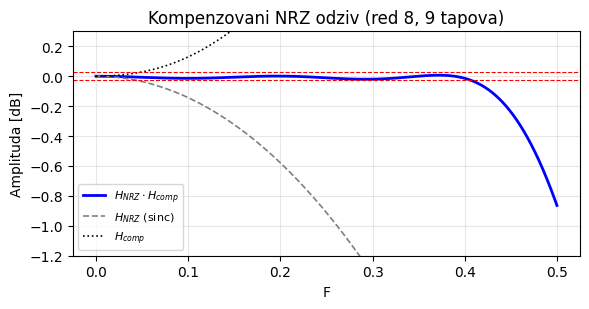

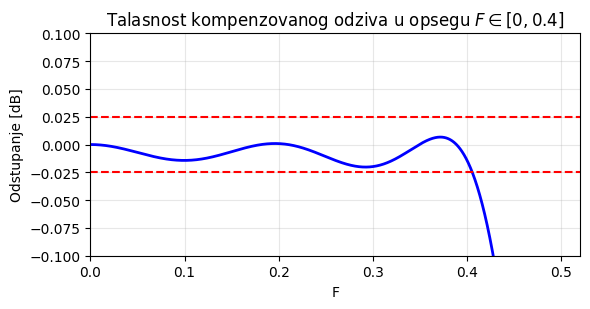

In [14]:
F, combdB, _ = combined_ripple(h_norm)
w, H = signal.freqz(h_norm, worN=8192)
idx = F <= 0.52

plt.figure(figsize=(6,3.2))
plt.plot(F[idx], combdB[idx], "b", lw=2, label="$H_{NRZ}\\cdot H_{comp}$")
plt.plot(F[idx], 20*np.log10(np.sinc(F[idx])), "--", color="gray", lw=1.2, label="$H_{NRZ}$ (sinc)")
plt.plot(F[idx], 20*np.log10(np.abs(H[idx])/np.abs(H[0])), ":", color="k", lw=1.2, label="$H_{comp}$")
plt.axhline(0.025, color="r", ls="--", lw=0.8); plt.axhline(-0.025, color="r", ls="--", lw=0.8)
plt.xlabel("F"); plt.ylabel("Amplituda [dB]")
plt.title(f"Kompenzovani NRZ odziv (red {numtaps-1}, {numtaps} tapova)")
plt.legend(fontsize=8, loc="lower left"); plt.grid(True, alpha=0.3); plt.ylim(-1.2, 0.3)
plt.tight_layout(); plt.savefig("kompenzacioni_filtar.png", dpi=130); plt.show()

plt.figure(figsize=(6,3.2))
plt.plot(F[idx], combdB[idx], "b", lw=2)
plt.axhline(0.025, color="r", ls="--"); plt.axhline(-0.025, color="r", ls="--")
plt.xlim(0, 0.52); plt.ylim(-0.1, 0.1)
plt.grid(True, alpha=0.3)
plt.xlabel("F"); plt.ylabel("Odstupanje [dB]")
plt.title("Talasnost kompenzovanog odziva u opsegu $F\\in[0,0.4]$")
plt.tight_layout(); plt.savefig("kompenzacioni_talasnost.png", dpi=130); plt.show()

### 4. zadatak

In [13]:
N = 10
SQNR = 6.02*N + 1.76
f = 0.9 * 16 * fs_in
print(f"SQNR = 6.02*{N} + 1.76 = {SQNR:.2f} dB")
print(f"f    = 0.9*16*fs = {f/1e6:.2f} MHz")

tj = 1.0/(2*np.pi*f*10**(SQNR/20))
print(f"\n10^(SQNR/20) = {10**(SQNR/20):.2f}")
print(f"2*pi*f       = {2*np.pi*f:.4e}")
print(f"tj_max = 1/(2*pi*f*10^(SQNR/20)) = {tj:.4e} s = {tj*1e15:.2f} fs")

SQNR = 6.02*10 + 1.76 = 61.96 dB
f    = 0.9*16*fs = 884.74 MHz

10^(SQNR/20) = 1253.14
2*pi*f       = 5.5590e+09
tj_max = 1/(2*pi*f*10^(SQNR/20)) = 1.4355e-13 s = 143.55 fs
